# Private synthesis of longitudinal individuals

1. Generate continuous logitudinal synthetic individuals.
2. Estimate changepoint (timepoints where the Bayesian network must be updated)
3. Estimate CPTs (Conditional Probability Tables)
4. Cluster CPTs
5. Generate synthetic individuals


## Generate individuals

In [19]:
#Generate dataset
import sys
import os
import numpy as np
sys.path.append(os.path.abspath('..')) 

num_individuals = 3
num_timepoints = 100
all_data = []
all_true_cps = []   # True change points (optional, for validation)

def generate_synthetic_data_2node_multicps(num_time_points=100, epsilon=0.5, snr=50):
    """Modified: 2-node network (X → X and X → Y) with 5 change points"""
    np.random.seed(42)
    m = num_time_points
    X = np.zeros(m)
    Y = np.zeros(m)
    phi_X = np.random.normal(0, 1, m)
    phi_Y = np.random.normal(0, 1, m)

    X[0] = np.random.normal(0, 1)
    beta = np.ones(m)

    # Define 5 equal segments
    segment_edges = np.linspace(0, m, 4, dtype=int)  # 4 points = 3 segments
    change_points = segment_edges[1:-1]  # inner edges are the CPs

    # Assign different beta values to each segment
    beta[segment_edges[0]:segment_edges[1]] = 1
    beta[segment_edges[1]:segment_edges[2]] = -2
    beta[segment_edges[2]:segment_edges[3]] = 1

    # Generate X (autoregressive)
    for t in range(1, m):
        X[t] = np.sqrt(1 - epsilon ** 2) * X[t - 1] + epsilon * phi_X[t]

    # Scale noise
    sigma_beta_X = np.std(beta * X)
    c = sigma_beta_X / snr

    # Generate Y (influenced by beta * X + noise)
    for t in range(m - 1):
        Y[t + 1] = beta[t] * X[t] + c * phi_Y[t + 1]

    data = np.vstack([X, Y])
    true_cps = [change_points.tolist(), change_points.tolist()]  # CPs for both X and Y
    return data, true_cps

for i in range(num_individuals):
    data_i, true_cps_i = generate_synthetic_data_2node_multicps(num_timepoints)
    all_data.append(data_i)
    all_true_cps.append(true_cps_i)

node_names = ["X", "Y"]

## Find changepoint

  0%|          | 0/3 [00:00<?, ?it/s]


=== Individual 1 ===
Learned Edge Probabilities (edges with prob > 0.5):
  Edge X → X: 1.000
  Edge X → Y: 1.000
Changepoints
  Node X: [] (K = 1)
  Node Y: [33, 63, 65] (K = 4)
Learned Change Points: [array([33, 63, 65]), array([33, 63, 65])]


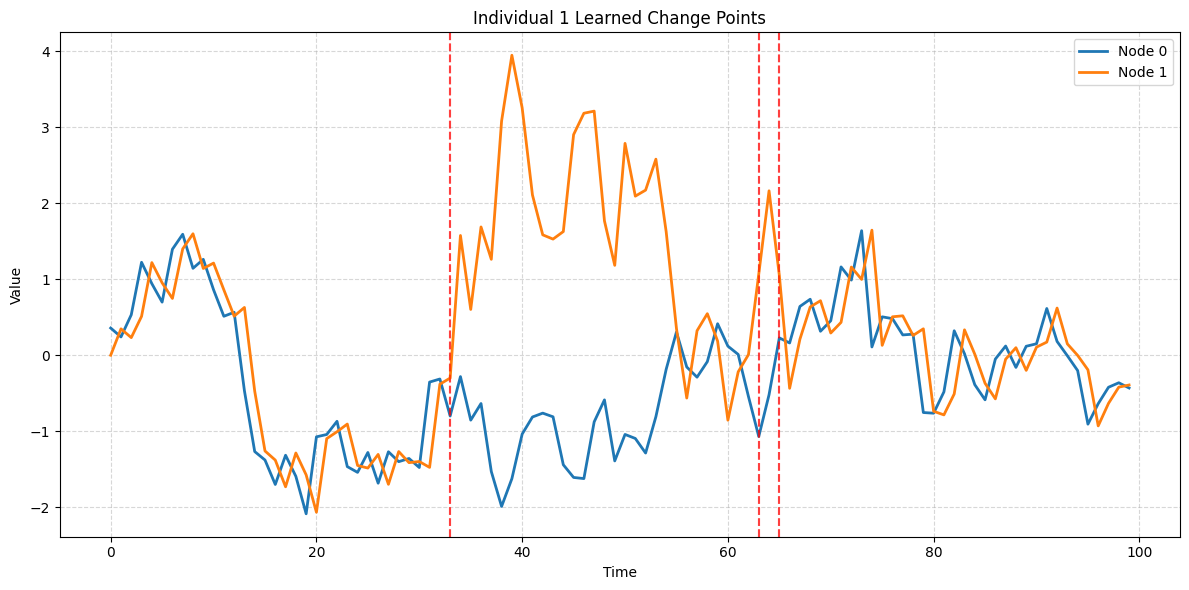

 33%|███▎      | 1/3 [01:46<03:32, 106.31s/it]


=== Individual 2 ===
Learned Edge Probabilities (edges with prob > 0.5):
  Edge X → X: 1.000
  Edge X → Y: 1.000
Changepoints
  Node X: [] (K = 1)
  Node Y: [30, 67] (K = 3)
Learned Change Points: [array([30, 67]), array([30, 67])]


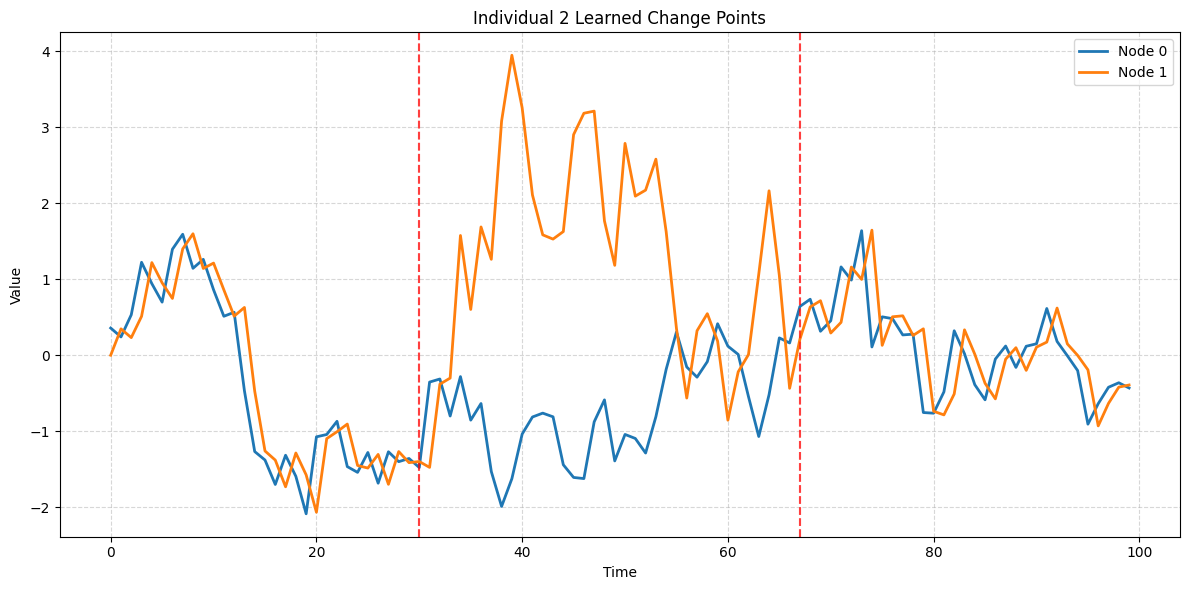

 67%|██████▋   | 2/3 [03:40<01:51, 111.15s/it]


=== Individual 3 ===
Learned Edge Probabilities (edges with prob > 0.5):
  Edge X → X: 1.000
  Edge X → Y: 0.996
  Edge Y → Y: 1.000
Changepoints
  Node X: [] (K = 1)
  Node Y: [27, 63, 65] (K = 4)
Learned Change Points: [array([27, 63, 65]), array([27, 63, 65])]


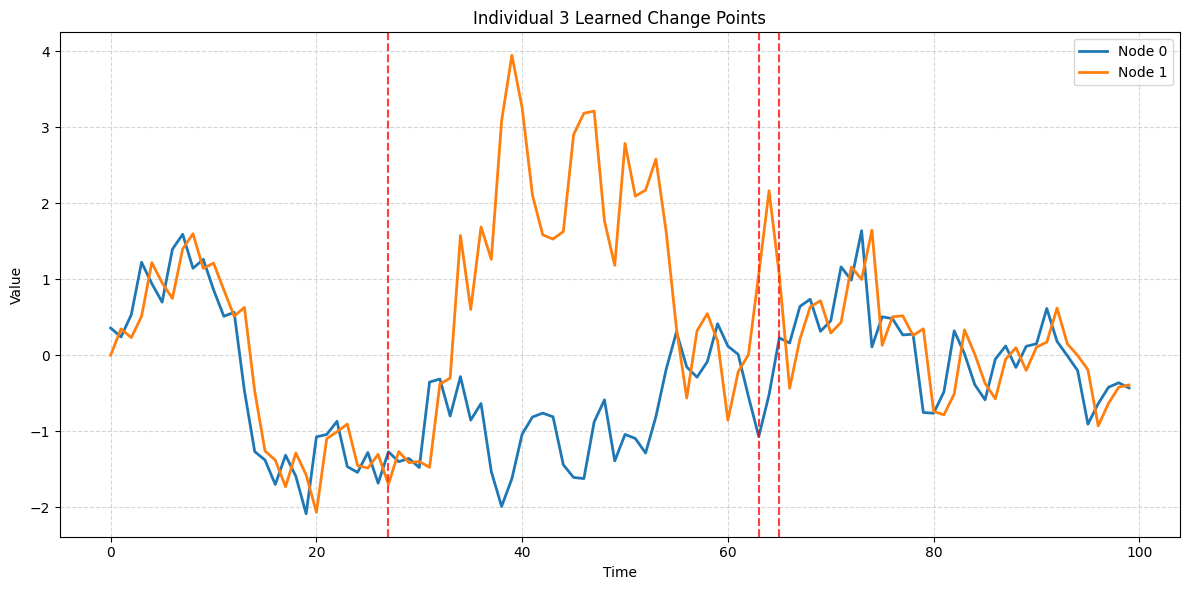

100%|██████████| 3/3 [05:31<00:00, 110.45s/it]


In [20]:
from tqdm import tqdm
from cpbge.mcmc import MCMC
from cpbge.plotting import plot_time_series_with_changepoints

def print_learned_structure(edge_probs, mean_K, allocation, node_names=None):
    """Prints edges and change points using readable node labels."""
    if node_names is None:
        node_names = [str(i) for i in range(len(mean_K))]

    print("Learned Edge Probabilities (edges with prob > 0.5):")
    for (u, v), prob in edge_probs.items():
        if prob > 0.5:
            print(f"  Edge {node_names[u]} → {node_names[v]}: {prob:.3f}")

    print("Changepoints")
    for node in range(allocation.shape[0]):
        cps = np.where(allocation[node, 1:] != allocation[node, :-1])[0]
        print(f"  Node {node_names[node]}: {cps.tolist()} (K = {len(cps)+1})")
    return cps


all_edge_probs = []
all_allocations = []
all_K = []
all_cps = []
i = 1

for data_i in tqdm(all_data):
    print(f"\n=== Individual {i} ===")
    
    model = MCMC(num_nodes=data_i.shape[0], max_segments=10)
    edge_probs, mean_K, allocation, samples = model.mcmc_inference(
        data_i, num_iterations=500000, burn_in=1000
    )

    cps = print_learned_structure(edge_probs, mean_K, allocation, node_names=node_names)
    cps = [cps] * len(node_names)
    print("Learned Change Points:", cps)
    # Collect outputs
    all_edge_probs.append(edge_probs)
    all_allocations.append(allocation)
    all_K.append(mean_K)
    all_cps.append(cps)

    plot_time_series_with_changepoints(data_i, cps, title=f"Individual {i} Learned Change Points")
    i+=1


## Estimate CPTs for each segment for each individual

In [21]:
import pandas as pd

# Discretize continuous time series data into bins
def discretize_segment_data(segment_data, num_bins=3):
    binned_data = np.zeros_like(segment_data, dtype=int)
    bin_edges = []
    bin_probs = []

    for i in range(segment_data.shape[0]):
        bins = np.histogram_bin_edges(segment_data[i], bins=num_bins)
        binned = np.digitize(segment_data[i], bins=bins[:-1], right=False) - 1
        counts = np.bincount(binned, minlength=num_bins)
        probs = counts / counts.sum()

        binned_data[i] = binned
        bin_edges.append(bins)
        bin_probs.append(probs)

    return binned_data, bin_edges, bin_probs

# Estimate conditional probability table: P(child[t] | parent[t−1])
def estimate_cpt(parent, child, num_bins):
    cpt = np.zeros((num_bins, num_bins))
    for t in range(1, len(parent)):
        p = parent[t - 1]
        c = child[t]
        cpt[p, c] += 1

    with np.errstate(invalid='ignore'):
        cpt = cpt / cpt.sum(axis=1, keepdims=True)

    return np.nan_to_num(cpt)

def get_segmentation(cps, data_length):
    """Get segmentation indices from change points."""
    #split cps into seperate lists for each element
    if isinstance(cps, list):
        # If cps is a list of lists, flatten it
        cps = [item for sublist in cps for item in sublist]
    elif isinstance(cps, np.ndarray):
        # If cps is a numpy array, convert to list
        cps = cps.tolist()

    segments = [0] + cps + [data_length]
    return segments

num_bins = 5

cpts = {}  # Store CPTs for each segment

for idx in tqdm(range(len(all_data))):
    data_i = all_data[idx]
    cps = all_cps[idx]
    segments = get_segmentation(cps[0], data_i.shape[1])
    i=0
    for i in range(len(segments) - 1):
        start, end = segments[i], segments[i + 1]
        segment_data = data_i[:, start:end]


        # Discretize the segment
        binned_data, bin_edges, bin_probs = discretize_segment_data(segment_data, num_bins)

        # Estimate CPTs: P(X[t] | X[t−1]) and P(Y[t] | X[t−1])
        cpt_X = estimate_cpt(binned_data[0], binned_data[0], num_bins)
        cpt_Y = estimate_cpt(binned_data[0], binned_data[1], num_bins)

        # Print results
        #print(f"\n=== Segment {i + 1}: Time [{start}, {end}) ===")
        #print("Bins for X:", bin_edges[0])
        #print("Bins for Y:", bin_edges[1])
        #print("P(X[t] | X[t−1]) CPT:")
        col_labels = [f"X={k}" for k in range(num_bins)]
        idx_labels = [f"X_prev={k}" for k in range(num_bins)]
        #display(pd.DataFrame(cpt_X, columns=col_labels, index=idx_labels))

        #print("\nP(Y[t] | X[t−1]) CPT:")
        col_labels_y = [f"Y={k}" for k in range(num_bins)]
        #display(pd.DataFrame(cpt_Y, columns=col_labels_y, index=idx_labels))
        #append cpt_X and cpt_Y to a dict for later use
        cpts[(idx, i)] = (cpt_X, cpt_Y)

    # Plot the globally discretized X and Y series with changepoints
    binned_full = np.zeros_like(data_i, dtype=int)
    for i in range(data_i.shape[0]):
        bins = np.histogram_bin_edges(data_i[i], bins=num_bins)
        binned_full[i] = np.digitize(data_i[i], bins=bins[:-1], right=False) - 1


100%|██████████| 3/3 [00:00<00:00, 407.39it/s]


## Flatten CPTs

In [ ]:
from sklearn.preprocessing import normalize
#Function for flattening cpts
def impute_normalize_flatten(cpt_array, epsilon=1e-8):
    """
    Impute NaNs, normalize, and flatten a CPT array
    """
    # Convert to numpy array if needed
    cpt_copy = np.copy(cpt_array)
    
    # Impute NaNs with epsilon
    cpt_copy = np.nan_to_num(cpt_copy, nan=epsilon)

    # Normalize each row to sum to 1 (for conditional probability tables)
    row_sums = cpt_copy.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # Avoid division by zero
    cpt_copy = cpt_copy / row_sums
    
    # Flatten the array
    return cpt_copy.flatten()

# Flatten all CPTs
cpts_flat = {}
print("Flattening CPTs...")

# pport any number of variables (nodes) in CPT flattening
for key, cpt_tuple in cpts.items():
    # Flatten each CPT in the tuple (one per node)
    cpts_flat[key] = {}
    combined = []
    for var_idx, cpt in enumerate(cpt_tuple):
        flat = impute_normalize_flatten(cpt)
        cpts_flat[key][f'cpt_{var_idx}_flat'] = flat
        combined.append(flat)
    # Combined feature vector for all variables in this segment
    cpts_flat[key]['segment_cpts'] = np.concatenate(combined)

print("Flattening complete.")

Flattening CPTs...
Flattening complete.


## Clustering CPT segments

Elbow at: 4


/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:1363: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:1363: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (11). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


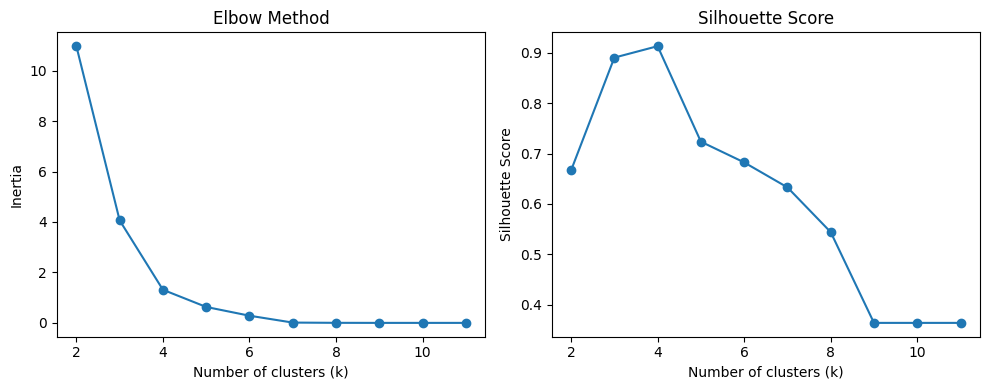

Cluster labels for each segment: [0 1 2 3 0 1 3 0 1 2 3]


In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

# Collect all segment_cpts into a single array for clustering
segment_cpts_list = [v['segment_cpts'] for v in cpts_flat.values()]
X = np.stack(segment_cpts_list)

# Use the elbow method to find optimal k
inertia = []
silhouette = []
# Compute cosine distance matrix (optional, for inspection)
cosine_dist = pairwise_distances(X, metric='cosine')

for k in range(2, len(segment_cpts_list)+1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = kmeans.fit_predict(X)
    inertia.append(kmeans.inertia_) # Inertia is the sum of squared distances to closest cluster center (k-means loss)
    # Silhouette score with cosine metric
    silhouette.append(silhouette_score(X, labels_k, metric='cosine'))
#%pip install kneed
from kneed import KneeLocator

# Using the KneeLocator to find the elbow point
# This will help us determine the optimal number of clusters (k)
# And it will allow us to adjust the sensitivity of the elbow detection
ks = range(2, len(inertia)+2)
knee = KneeLocator(ks, inertia, curve="convex", direction="decreasing")
print("Elbow at:", knee.knee)

# Plot inertia and silhouette scores
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(range(2, len(segment_cpts_list)+1), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1,2,2)
plt.plot(range(2, len(segment_cpts_list)+1), silhouette, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.tight_layout()
plt.show()

# Choose k (for example, by elbow or silhouette)
optimal_k = knee.knee if knee.knee else 3  # Default to 3 if no knee found
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

print("Cluster labels for each segment:", labels)

/var/folders/_h/mf70q7412jb3711dk_rzmys40000gp/T/ipykernel_87238/3158178869.py:12: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(centers[i, 0], centers[i, 1], color=palette[i], marker='x', s=200, label=f'Cluster {i} Center', edgecolor='k', linewidth=2)


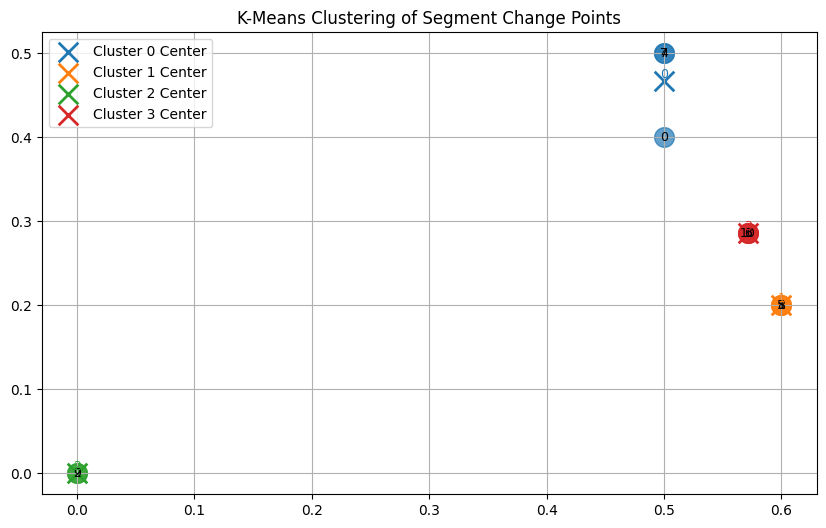

In [25]:
import seaborn as sns
# Visualize clusters and centers
centers = kmeans.cluster_centers_
plt.figure(figsize=(10, 6))
palette = sns.color_palette("tab10", np.max(labels) + 1)
# Add labels to each point in the scatter plot
for idx, (x, y) in enumerate(X[:, :2]):
    plt.text(x, y, str(idx), fontsize=9, ha='center', va='center', color='black')
    plt.scatter(x, y, marker='o', s=200, alpha=0.7, color=palette[labels[idx]])
for i in range(len(centers)):
    plt.text(centers[i, 0], centers[i, 1], str(i), fontsize=9, ha='center', va='bottom', color=palette[i])
    plt.scatter(centers[i, 0], centers[i, 1], color=palette[i], marker='x', s=200, label=f'Cluster {i} Center', edgecolor='k', linewidth=2)
plt.title('K-Means Clustering of Segment Change Points')
plt.legend()
plt.grid(True)

In [27]:
from sklearn.metrics import pairwise_distances_argmin_min

# Find the segment CPT closest to each cluster centroid


# X: array of all segment_cpts (already defined)
# centers: cluster centroids from kmeans (already defined)

# Find the index of the closest segment to each centroid
closest_indices, distances = pairwise_distances_argmin_min(centers, X)

# Map back to segment keys
segment_keys = list(cpts_flat.keys())
closest_segments = {cluster: segment_keys[idx] for cluster, idx in enumerate(closest_indices)}

print("Closest segment CPT to each cluster centroid:")
for cluster, seg_key in closest_segments.items():
    print(f"  Cluster {cluster}: Segment {seg_key} (distance={distances[cluster]:.4f})")

Closest segment CPT to each cluster centroid:
  Cluster 0: Segment (1, 0) (distance=0.2414)
  Cluster 1: Segment (1, 1) (distance=0.2785)
  Cluster 2: Segment (0, 2) (distance=0.0000)
  Cluster 3: Segment (0, 3) (distance=0.0401)


In [34]:
# Compute Transition Matrix
# Shows how segments transition from one cluster to another across time for each individual

# First, we need to map each segment back to its individual and temporal order
segment_to_individual = {}
segment_to_order = {}
segment_to_cluster = {}

# Build the mapping from segment index to individual and temporal order
segment_idx = 0
for individual_idx in range(len(all_data)):
    cps = all_cps[individual_idx]
    segments = get_segmentation(cps[0], all_data[individual_idx].shape[1])
    
    for seg_order in range(len(segments) - 1):
        segment_to_individual[segment_idx] = individual_idx
        segment_to_order[segment_idx] = seg_order
        segment_to_cluster[segment_idx] = labels[segment_idx]
        segment_idx += 1

print(f"Total segments: {segment_idx}")
print(f"Number of clusters: {optimal_k}")

# Initialize transition matrix
transition_matrix = np.zeros((optimal_k, optimal_k))
total_transitions = 0

# Count transitions for each individual
for individual_idx in range(len(all_data)):
    # Get all segments for this individual in temporal order
    individual_segments = [(idx, segment_to_order[idx], segment_to_cluster[idx]) 
                          for idx in range(len(labels)) 
                          if segment_to_individual[idx] == individual_idx]
    
    # Sort by temporal order
    individual_segments.sort(key=lambda x: x[1])
    
    print(f"Individual {individual_idx}: {len(individual_segments)} segments")
    print(f"  Cluster sequence: {[seg[2] for seg in individual_segments]}")
    
    # Count transitions between consecutive segments
    for i in range(len(individual_segments) - 1):
        current_cluster = individual_segments[i][2]
        next_cluster = individual_segments[i + 1][2]
        transition_matrix[current_cluster, next_cluster] += 1
        total_transitions += 1

print(f"\nTotal transitions counted: {total_transitions}")

# Normalize to get probabilities
transition_probabilities = transition_matrix.copy()
row_sums = transition_matrix.sum(axis=1)
for i in range(optimal_k):
    if row_sums[i] > 0:
        transition_probabilities[i] = transition_matrix[i] / row_sums[i]

print("\nTransition Matrix (raw counts):")
print(transition_matrix)
print("\nTransition Probabilities:")
print(transition_probabilities)

Total segments: 11
Number of clusters: 4
Individual 0: 4 segments
  Cluster sequence: [0, 1, 2, 3]
Individual 1: 3 segments
  Cluster sequence: [0, 1, 3]
Individual 2: 4 segments
  Cluster sequence: [0, 1, 2, 3]

Total transitions counted: 8

Transition Matrix (raw counts):
[[0. 3. 0. 0.]
 [0. 0. 2. 1.]
 [0. 0. 0. 2.]
 [0. 0. 0. 0.]]

Transition Probabilities:
[[0.         1.         0.         0.        ]
 [0.         0.         0.66666667 0.33333333]
 [0.         0.         0.         1.        ]
 [0.         0.         0.         0.        ]]


In [ ]:
import numpy as np

# Compute initial cluster probabilities from the first segment of each individual
initial_clusters = [segment_to_cluster[idx] for idx in range(len(segment_to_cluster)) if segment_to_order[idx] == 0]
unique, counts = np.unique(initial_clusters, return_counts=True)
initial_cluster_probs = np.zeros(optimal_k)
initial_cluster_probs[unique] = counts / np.sum(counts)
print("Initial cluster probabilities:", initial_cluster_probs)

# Sample an initial cluster for a synthetic individual
sampled_initial_cluster = np.random.choice(np.arange(optimal_k), p=initial_cluster_probs)
print("Sampled initial cluster:", sampled_initial_cluster)

# Get the segment key for the first segment of the sampled initial cluster
# Find the first segment (order 0) for any individual with the sampled_initial_cluster label
seg_key = None
for idx in range(len(segment_to_cluster)):
    if segment_to_order[idx] == 0 and segment_to_cluster[idx] == sampled_initial_cluster:
        seg_key = segment_keys[idx]
        break

if seg_key is not None:
    initial_cpt = cpts_flat[seg_key]
    print(f"CPT for initial cluster (cluster {sampled_initial_cluster}, segment {seg_key}):")
    print(initial_cpt)
else:
    print(f"No segment found for initial cluster {sampled_initial_cluster}")



Initial cluster probabilities: [1. 0. 0. 0.]
Sampled initial cluster: 0
